# Laboppgave 1: Sampling og frekvensinnhold

**Lab 1, PHYS116**  
**Navn:** Rapport Lab1  
**Dato:** [fyll inn dato]


## Erklæring

### Erklæring om arbeidsfordeling
*Her skriver dere kort om hvordan dere har samarbeidet i arbeidet med denne oppgaven. Husk at alle i gruppen er ansvarlig for hele besvarelsen*
Vi startet oppgaven sammen etter pre-lab. Bestemte oss for å lage en git for å samarbeide remote. Alle deltok i alle besvarelser på alle oppgaver.

### Erklæring om bruk av KI
*Se retningslinjene her: https://www.uib.no/nt/177637/bruk-av-kunstig-intelligens-ki-ved-fakultet-naturvitenskap-og-teknologi. Hvis dere har brukt KI så må dere skrive veldig kort hva dette har blitt brukt til, og hvilke verktøy dere har brukt til hva. Husk at dere som gruppe uansett er 100% ansvarlig for arbeidet dere leverer inn.*

Har CoPilot installert hvor den kommer med forslag til kode live.



## Målsetting

Beskriv kort formålet med laboratorieøvelsen og hvilke fenomener
som undersøkes. Forklar hva som studeres, for eksempel sammenhengen mellom
sampling, frekvensinnhold, FFT og aliasing.

Presenter kort problemstillingen og hva som skal undersøkes i laboppgaven.

Formålet med laboratorieøvelsen er å undersøke hvordan samplingfrekvensen påvirker hvordan periodiske signaler blir representert i tids- og frekvensdomenet. For å gjøre dette skal vi se på sammenhengen mellom sampling, Nyquist-frekvensen, FFT og aliasing. I tillegg vil vi undersøke hvordan et firkantsignal kan bygges opp av odde harmoniske komponenter, og hvordan disse påvirkes av samplingfrekvensen.

## 1. Metode


Beskriv hvordan signalene ble generert og analysert. Presenter implementasjonen som ble brukt, og forklar hvilke parametere som ble valgt for simuleringene.

### 1.1 Referansemåling

In [66]:
import matplotlib.pyplot as plt
import numpy as np

import sounddevice as sd


In [67]:
# Her vises et eksempel på hvordan man kommentere en funksjon i Python slik at man får hjelp når man bruker funksjonen. Dette kalles docstring og er en del av PEP 257.

def syn_sin(fk, Xk, fs, dur, tstart=0.0):
    """
    Syntetiserer et signal basert på gitte frekvenser og komplekse amplituder.

    Args:
        fk (array-like): Frekvensene til de harmoniske komponentene.
        Xk (array-like): Komplekse amplituder for de harmoniske komponentene.
        fs (float): Samplingsfrekvens.
        dur (float): Varighet av signalet i sekunder.
        tstart (float, optional): Starttid for signalet. Default er 0.

    Returns:
        tuple: En tuple som inneholder:
            - xx (numpy.ndarray): Det syntetiserte signalet.
            - tt (numpy.ndarray): Tidsvektor for signalet.
    """
    fk = np.asarray(fk, dtype=float)
    Xk = np.asarray(Xk, dtype=complex)

    N = int(round(fs * dur))
    tt = tstart + np.arange(N) / fs

    amplitudes = np.abs(Xk)[:, None]
    phases = np.angle(Xk)[:, None]
    frequencies = fk[:, None]

    xx = np.sum( amplitudes * np.cos(2 * np.pi * frequencies * tt + phases), axis=0, )

    return xx, tt

In [68]:
# Oppgave: Lag tilsvarende kommentar som det er gjort for syn_sin()

def amplitude_spectrum(signal, fs):
    """
    Beregner amplitudespekteret til et signal ved hjelp av FFT.

    Args:
        signal (array): Inputsignalet som skal analysers
        fs (float): Samplingsfrekvensen
    Returns:
        tuple: En tuple som inneholder:
            - freq (numpy.ndarray): Frekvensene
            - amplitude (numpy.ndarray: Amplitduene).
    """    
    signal = np.asarray(signal, dtype=float)
    signal = signal - np.mean(signal)

    N = len(signal)
    X = np.fft.rfft(signal)

    freq = np.fft.rfftfreq(N, d=1/fs)
    amplitude = np.abs(X) / N
    amplitude[1:-1] *= 2

    return freq, amplitude

Text(0, 0.5, 'Amplitude')

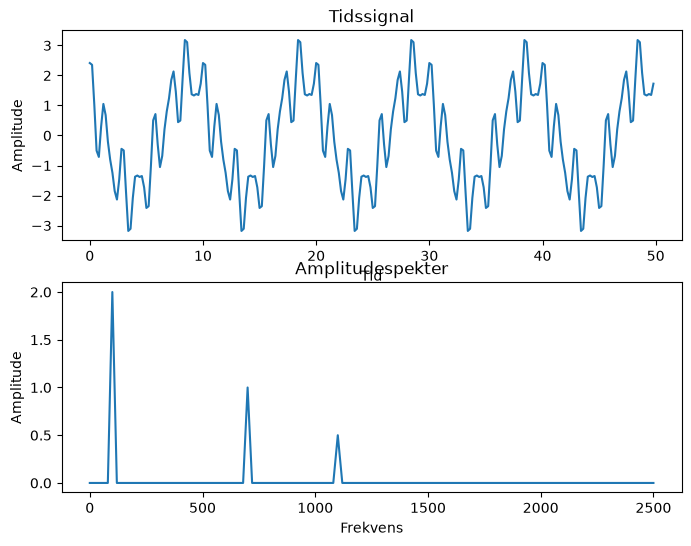

In [69]:
# Egen kode med kommentarer
#Gir variablene verdiene fra pre-labben
pi = np.pi 
fk = np.array([100, 700, 1100]) #frekvensene
Ak = np.array([2.0, 1.0, 0.5])#amplitudene
phi = np.array([pi /4, 0, -pi/2]) #fasene
Xk = Ak * np.exp(1j * phi) 
fs = 5000 #samplingsfrekvens
dur = 0.05 #måletid

# Generer signalet:
xx, tt = syn_sin(fk, Xk, fs, dur)
freq, amplitude = amplitude_spectrum(xx, fs)

#gir plass til begge figurene:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

#tidsplott og et enkeltsidig amplitudespekter 
ax1.plot(tt * 1000, xx)
ax1.set_title("Tidssignal")
ax1.set_xlabel("Tid")
ax1.set_ylabel("Amplitude")

ax2.plot(freq, amplitude)
ax2.set_title("Amplitudespekter")
ax2.set_xlabel("Frekvens")
ax2.set_ylabel("Amplitude")

In [70]:
# kontroller at de tre frekvenskomponentene kan identifiseres i FFT plottet, og sammenlign amplitudene
for i in range(len(fk)):
    idx = np.argmin(np.abs(freq - fk[i]))
    print(f"f = {freq[idx]:.1f} Hz, funnet amplitude = {amplitude[idx]:.3f}, brukt amplitude = {Ak[i]:.3f}")

# avstand mellom frekvenspunktene i FFT-plottet, sammenlignet med df = 1/Tmålt
df_fft = freq[1] - freq[0]
df_teori = 1 / dur
print(f"df fra FFT: {df_fft:.2f} Hz, df = 1/Tmålt: {df_teori:.2f} Hz")

f = 100.0 Hz, funnet amplitude = 2.000, brukt amplitude = 2.000
f = 700.0 Hz, funnet amplitude = 1.000, brukt amplitude = 1.000
f = 1100.0 Hz, funnet amplitude = 0.500, brukt amplitude = 0.500
df fra FFT: 20.00 Hz, df = 1/Tmålt: 20.00 Hz




### 1.2 Aliasing av sammensatte sinuser

Samme signal som i 1.1, samplet med fem ulike samplingsfrekvenser fra oppgaveteksten, generert med funksjonen syn_sin(). For hver f_s lages tidsplott og amplitudespekteret beregnes med funksjonen amplitude_spectrum() og plottes. Deretter: Nyquist-frekvensen blir markert, og observerte topper blir sammenlignet med de opprinnelige frekvenser for å se hvilke som blir foldet.

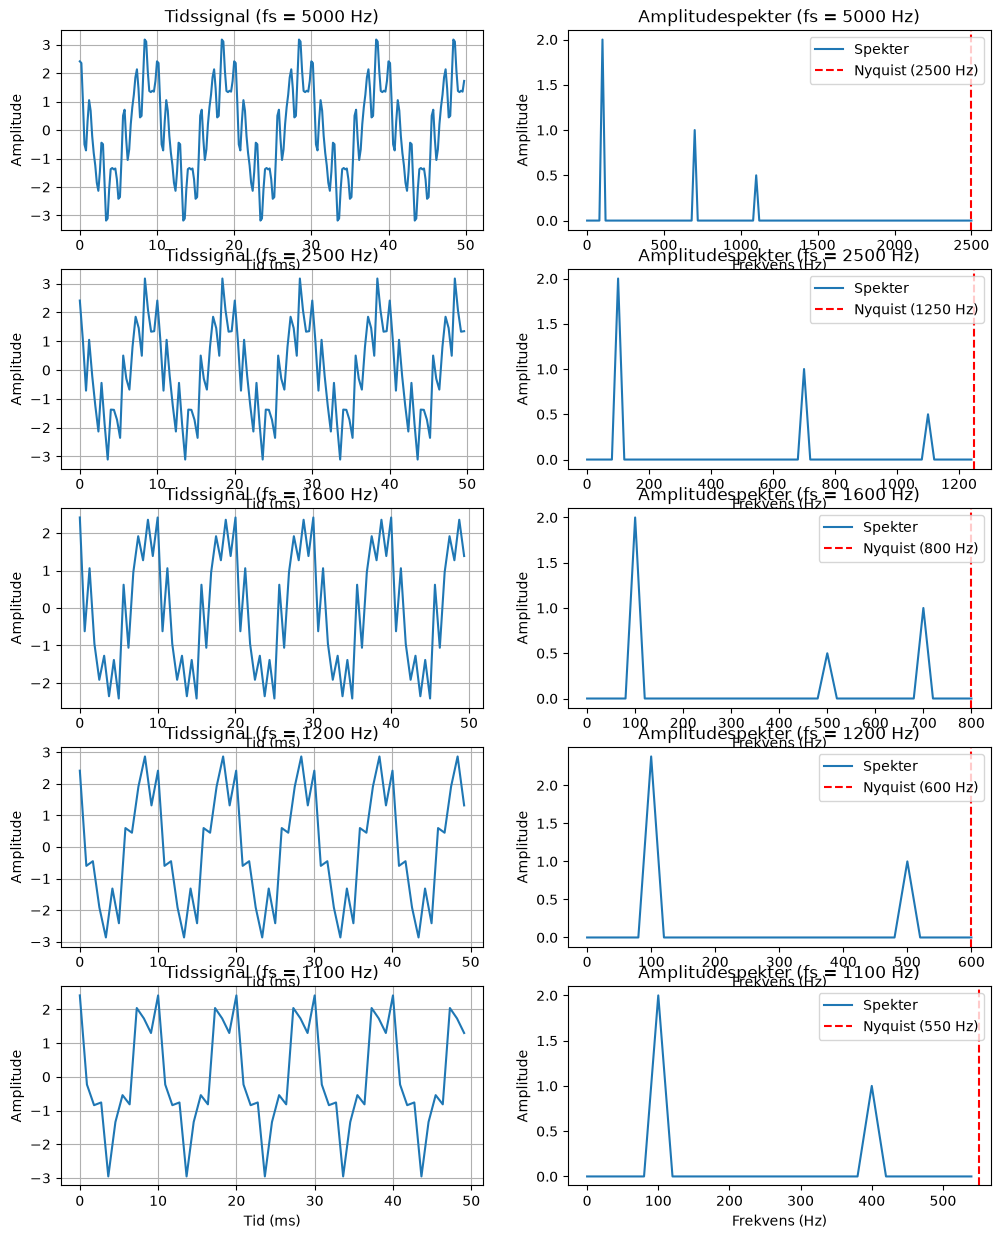

In [71]:
#Egen kode med kommentarer
f_s = 5000, 2500, 1600, 1200, 1100 #Samplingfrekvensene

fig, axes = plt.subplots(len(f_s), 2, figsize=(12, 3 * len(f_s)))
for i, fs in enumerate(f_s):
    xx, tt = syn_sin(fk, Xk, fs, dur)
    freq, amplitude = amplitude_spectrum(xx, fs)
    ax_time = axes[i, 0]
    ax_freq = axes[i, 1]
    
    # Tidsplott
    ax_time.plot(tt * 1000, xx)
    ax_time.set_title(f"Tidssignal (fs = {fs} Hz)")
    ax_time.set_xlabel("Tid (ms)")
    ax_time.set_ylabel("Amplitude")
    ax_time.grid(True)
    
    # Frekvensplott
    ax_freq.plot(freq, amplitude, label="Spekter")
    
    #nyquistplott
    f_nyq = fs / 2
    ax_freq.axvline(f_nyq, color='r', linestyle='--', label=f'Nyquist ({f_nyq:.0f} Hz)')
    
    ax_freq.set_title(f"Amplitudespekter (fs = {fs} Hz)")
    ax_freq.set_xlabel("Frekvens (Hz)")
    ax_freq.set_ylabel("Amplitude")
    ax_freq.legend(loc='upper right')

In [72]:
if sd is not None:
    signal = xx
    samplingsfrekvens = fs
    audio = signal / np.max(np.abs(signal))
    sd.play(audio, samplingsfrekvens)
    sd.wait()
else:
    print("sounddevice er ikke tilgjengelig i denne kernelen, så lydavspilling hoppes over.")

### 1.3 Firkantsignal og harmoniske komponenter

In [73]:
F0 = 500
A = 1.0

N = 2  # antall harmoniske

n = np.arange(1, 2*N, 2)  # oddetallene
harmonics = n * F0        # odde harmoniske av F0

Ak = 4 * A / (np.pi * n)  # amplituden til hver harmoniske

phik = -np.pi/2 * np.ones(N)  # fase til alle komponentene

Xk = Ak * np.exp(1j * phik)   # kombinerer amplitude og fase

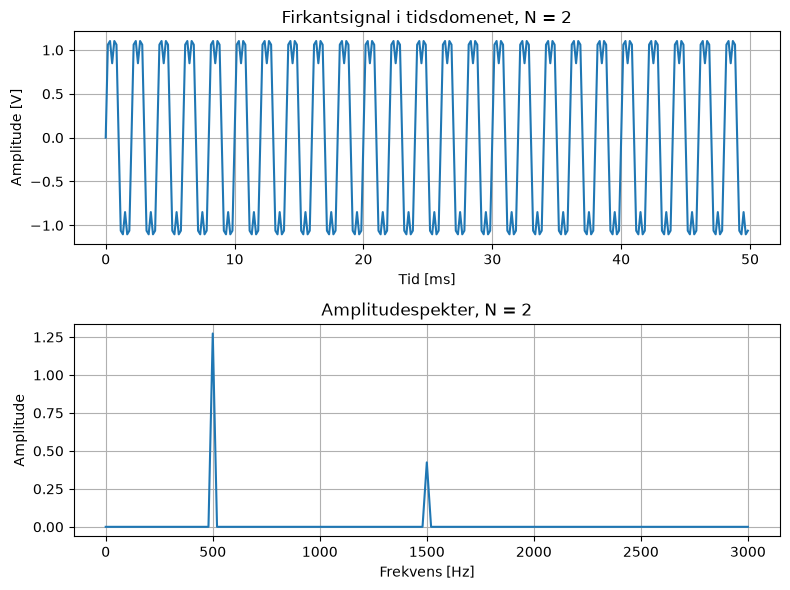

In [74]:
# Egen Kode med kommentarer
fs = 4 * (2*N - 1) * F0

# Lager signalet med tildligere gitt funksjon
signal, t = syn_sin(
    fk=harmonics,
    Xk=Xk,
    fs=fs,
    dur=dur,
)

# Lager amplitude sprektrum med tidligere gitt funksjon
freq, amplitude = amplitude_spectrum(signal, fs)

# Initialiserer plottene som skal brukes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Tidsplott
ax1.plot(t * 1000, signal)
ax1.set_title("Firkantsignal i tidsdomenet, N = 2")
ax1.set_xlabel("Tid [ms]")
ax1.set_ylabel("Amplitude [V]")
ax1.grid(True)

# Frekvensplott
ax2.plot(freq, amplitude)
ax2.set_title("Amplitudespekter, N = 2")
ax2.set_xlabel("Frekvens [Hz]")
ax2.set_ylabel("Amplitude")
ax2.grid(True)

plt.tight_layout()
plt.show()

Når N = 2 har firknatsignalet kun de 2 første odde harmoniske komponentene. F0 = 500hz så grunnfrekvensen er 500hz, og den neste odde harmoniske komponenten er 3F0 = 1500hz. Derfor vil amplitudespekteret vise topper i de sistnevnte frekvensene, 500hz og 1500hz.

2 harmoniske komponenter er lite for et firkantsignal, og vil kun gi en grov tilnærming. Vi kan se i tidsplottet at kantene er avrundet, så flere harmoniske komponenter trengs for å få et mer nøykayig firkantsignal.

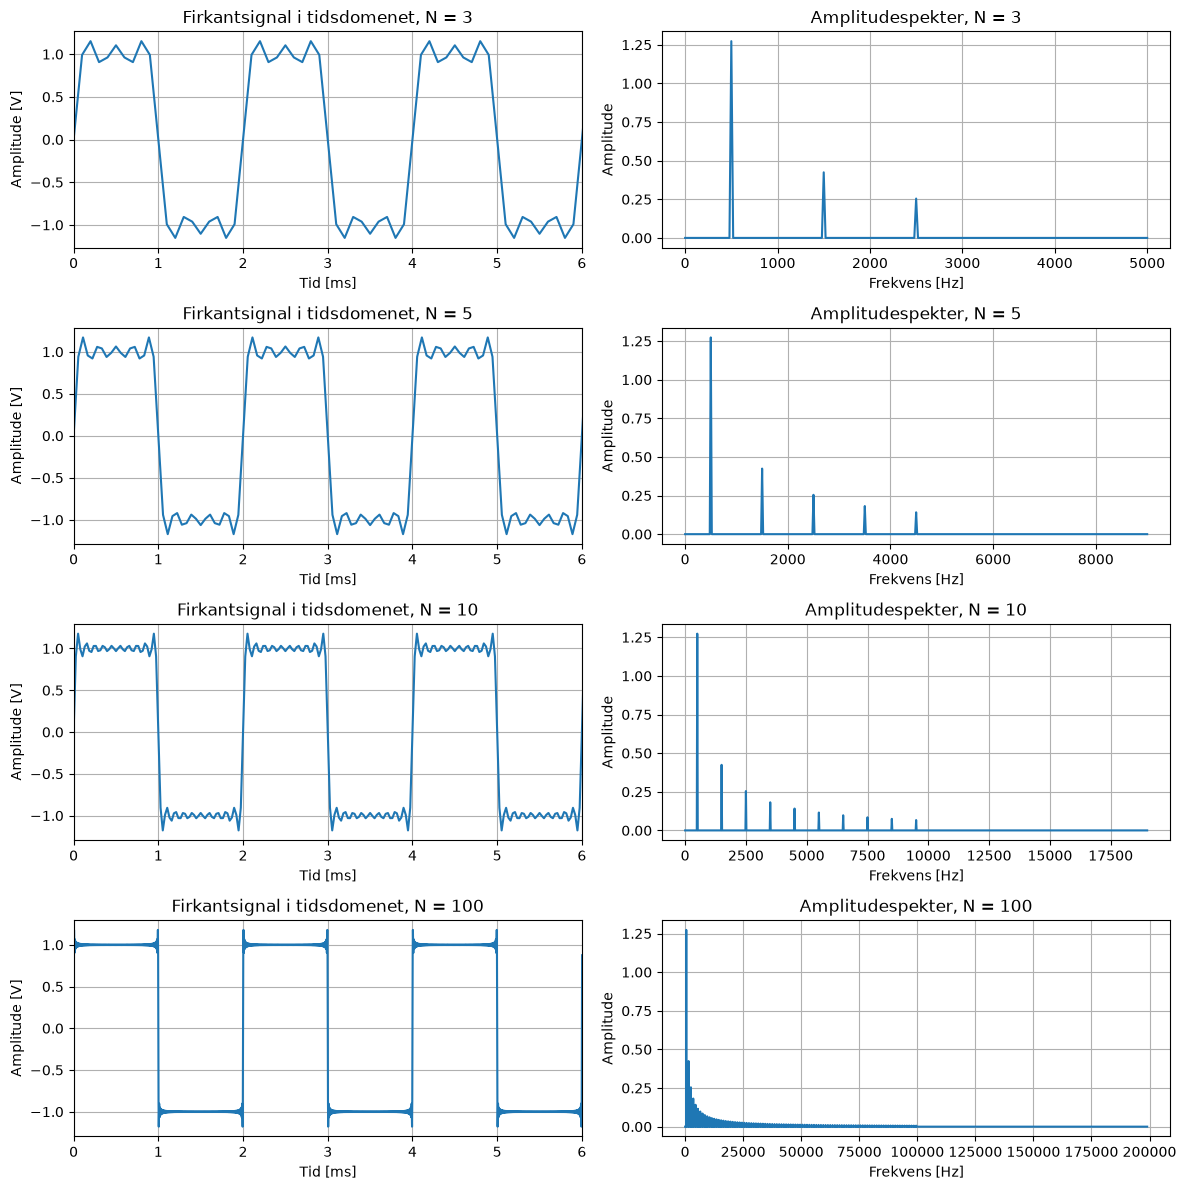

In [75]:
N_values = [3, 5, 10, 100] # Verdier for antall harmoniske komponenter

# Initialiserer plottene som skal brukes
fig, axes = plt.subplots(len(N_values), 2, figsize=(12, 12))

# Går gjennom hver N-verdi og lager nytt signal og spekter
for i, N in enumerate(N_values):
    n = np.arange(1, 2*N, 2) # Oddetallene
    harmonics = n * F0 # oddeharmoniske av F0
    Ak = 4 * A / (np.pi * n) # Amplituden til hver harmoniske
    phik = -np.pi/2 * np.ones(N) # Fase til alle komponentene
    Xk = Ak * np.exp(1j * phik) # kombinerer amplitude og fase

    fs = 4 * (2*N - 1) * F0

    # Lager signalet med tidligere gitt funksjon
    signal, t = syn_sin(
        fk=harmonics,
        Xk=Xk,
        fs=fs,
        dur=dur,
    )

    # Lager amplitude sprektrum med tidligere gitt funksjon
    freq, amplitude = amplitude_spectrum(signal, fs)

    # Tidsplott
    axes[i, 0].plot(t * 1000, signal)
    axes[i, 0].set_xlim(0, 6)
    axes[i, 0].set_title(f"Firkantsignal i tidsdomenet, N = {N}")
    axes[i, 0].set_xlabel("Tid [ms]")
    axes[i, 0].set_ylabel("Amplitude [V]")
    axes[i, 0].grid(True)

    # Frekvensplott
    axes[i, 1].plot(freq, amplitude)
    axes[i, 1].set_title(f"Amplitudespekter, N = {N}")
    axes[i, 1].set_xlabel("Frekvens [Hz]")
    axes[i, 1].set_ylabel("Amplitude")
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

N verdien forteller hvor mange oddeharmoniske komponenter er i firkantsignalet. Når for eksempel N = 3 inneholder firkantsignalet 500hz, 1500hz og 2500hz, dette ser vi som topper i amplitudespekteret ved de nevnte frekvensene. Jo større N, jo flere og høygere frekvenser.

I tidsplottene ser vi at når N øker, blir firkantsignalet mer firkantet og presist. Høyere og flere harmoniske komponenter bidrar til at signalet får raske overganger, som gir signalet bratte kanter, og flate topper og bunner.

Samtidig ser vi små svingninger og litt overshoot nær de bratte overgangene i 
signalet. Dette skjer fordi vi prøver å lage et signal med skarpe kanter ved å 
summere flere sinuskomponenter. Sinuskomponentene er glatte kurver, så de klarer 
ikke å lage en helt pergekt vinkel. Når N øker, blir signalet mer nøyaktig, men 
det er fortsatt litt overshoot nær kantene.

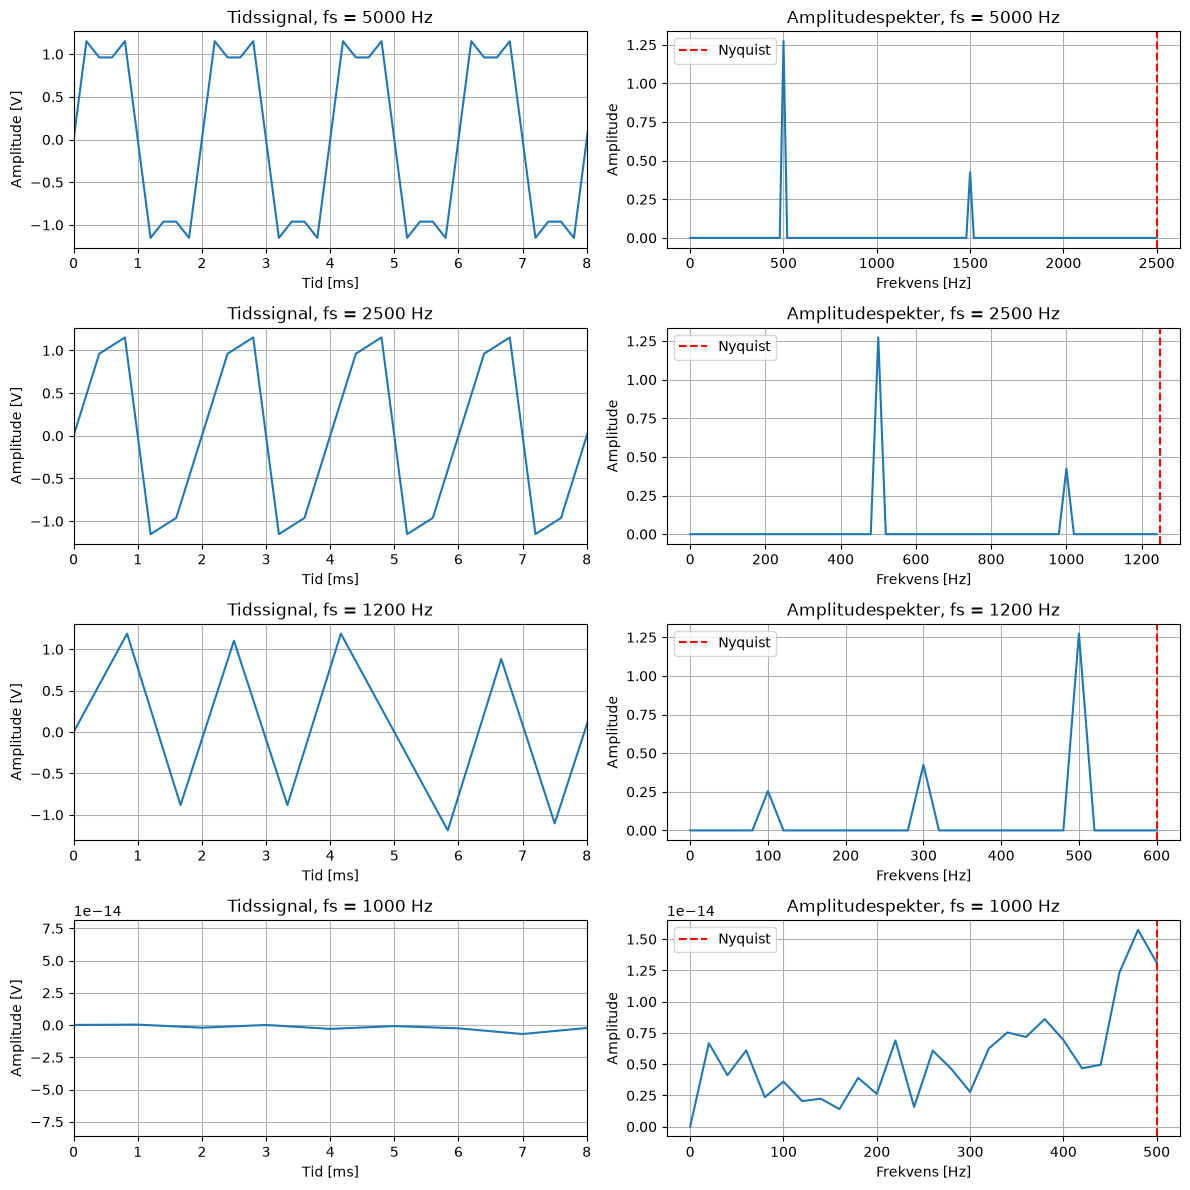

In [76]:
N = 3  # antall harmoniske

n = np.arange(1, 2*N, 2)  # oddetallene
harmonics = n * F0  # odde harmoniske av F0
Ak = 4 * A / (np.pi * n)  # amplituden til hver harmoniske
phik = -np.pi/2 * np.ones(N)  # fase til alle komponentene
Xk = Ak * np.exp(1j * phik)  # kombinerer amplitude og fase

sampling_rates = [5000, 2500, 1200, 1000]  # samplingsfrekvensene

# Initialiserer plottene som skal brukes
fig, axes = plt.subplots(len(sampling_rates), 2, figsize=(12, 12))

# Itererer over sampling_rates for å lage ett plot for hver samplingsfrekvens
for i, fs in enumerate(sampling_rates):
    # Lager signalet med tidligere gitt funksjon
    signal, t = syn_sin(
        fk=harmonics,
        Xk=Xk,
        fs=fs,
        dur=dur,
    )

    # Lager amplitudespekteret med tidligere gitt funksjon
    freq, amplitude = amplitude_spectrum(signal, fs)

    # Regner ut Nyquist-frekvensen
    f_nyq = fs / 2

    # Tidsplott
    axes[i, 0].plot(t * 1000, signal)
    axes[i, 0].set_xlim(0, 8)
    axes[i, 0].set_title(f"Tidssignal, fs = {fs} Hz")
    axes[i, 0].set_xlabel("Tid [ms]")
    axes[i, 0].set_ylabel("Amplitude [V]")
    axes[i, 0].grid(True)

    # Frekvensplott
    axes[i, 1].plot(freq, amplitude)
    axes[i, 1].axvline(f_nyq, color="r", linestyle="--", label="Nyquist")
    axes[i, 1].set_title(f"Amplitudespekter, fs = {fs} Hz")
    axes[i, 1].set_xlabel("Frekvens [Hz]")
    axes[i, 1].set_ylabel("Amplitude")
    axes[i, 1].legend()
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

Når N = 3 består firkantsignalet av frekvensene 500 Hz, 1500 Hz og 2500 Hz. 
For hver samplingsfrekvens må vi sammenligne disse frekvensene med 
Nyquist-frekvensen, som er fs/2. Frekvenser over Nyquist-frekvensen vil 
aliaseres, og vises som lavere frekvenser i amplitudespekteret.

Ved fs = 5000 Hz er Nyquist-frekvensen 2500 Hz, så frekvensene ligger under 
eller akkurat på grensen. Når fs senkes til 2500 Hz, 1200 Hz og 1000 Hz, ligger 
flere av de harmoniske komponentene over Nyquist-frekvensen. Da blir de foldet 
til lavere frekvenser, og amplitudespekteret viser ikke lenger de opprinnelige 
harmoniske komponentene riktig.

Dette påvirker også tidsplottet, fordi de høye harmoniske komponentene er viktige 
for å lage de bratte kantene i firkantsignalet. Når disse aliaseres, blir signalet 
dårligere representert.

## 2. Resultater

### 2.1 Referansemåling

Presenter tidsplott og amplitudespekter for referansemålingen.


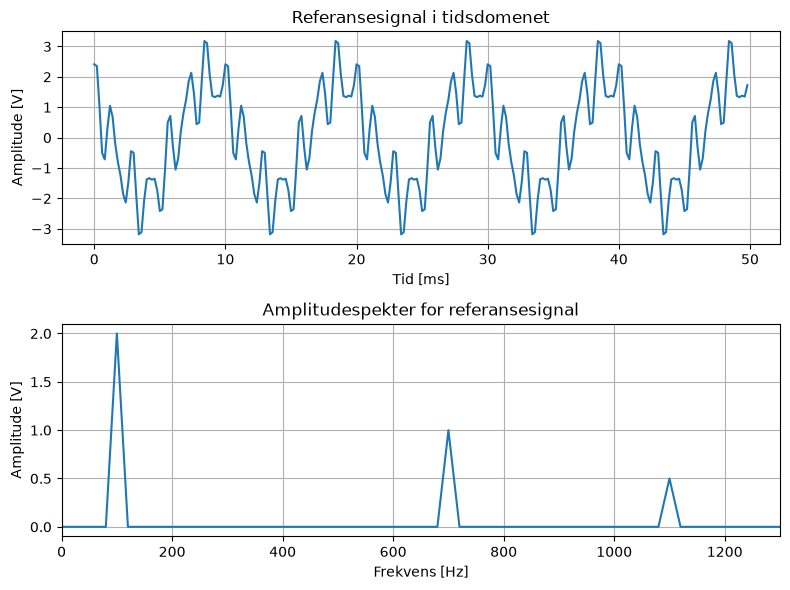

In [77]:
# Lager referansesignalet på nytt fordi variablene ble endret i 1.2 og 1.3
fk_ref = np.array([100, 700, 1100])
Ak_ref = np.array([2.0, 1.0, 0.5])
phi_ref = np.array([np.pi / 4, 0, -np.pi / 2])
Xk_ref = Ak_ref * np.exp(1j * phi_ref)

fs_ref = 5000
dur_ref = 0.05

xx_ref, tt_ref = syn_sin(fk_ref, Xk_ref, fs_ref, dur_ref)
freq_ref, amplitude_ref = amplitude_spectrum(xx_ref, fs_ref)

# Plotter referansemålingen
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Tidsplott
ax1.plot(tt_ref * 1000, xx_ref)
ax1.set_title("Referansesignal i tidsdomenet")
ax1.set_xlabel("Tid [ms]")
ax1.set_ylabel("Amplitude [V]")
ax1.grid(True)

# Frekvensplott
ax2.plot(freq_ref, amplitude_ref)
ax2.set_title("Amplitudespekter for referansesignal")
ax2.set_xlabel("Frekvens [Hz]")
ax2.set_ylabel("Amplitude [V]")
ax2.set_xlim(0, 1300)
ax2.grid(True)

plt.tight_layout()
plt.show()

**Figurtekst:**

Figuren viser referansesignalet i tidsdomenet og amplitudespekteret til signalet. Signalet er satt sammen av tre sinuskomponenter med frekvensene 100 Hz, 700 Hz og 1100 Hz. I amplitudespekteret ser vi topper ved de samme frekvensene. Amplitudene er omtrent 2.0, 1.0 og 0.5, som stemmer med verdiene som ble brukt i koden.


### 2.2 Aliasing

Presenter resultatene for de ulike samplingsfrekvensene og identifiser
observerte aliasfrekvenser.

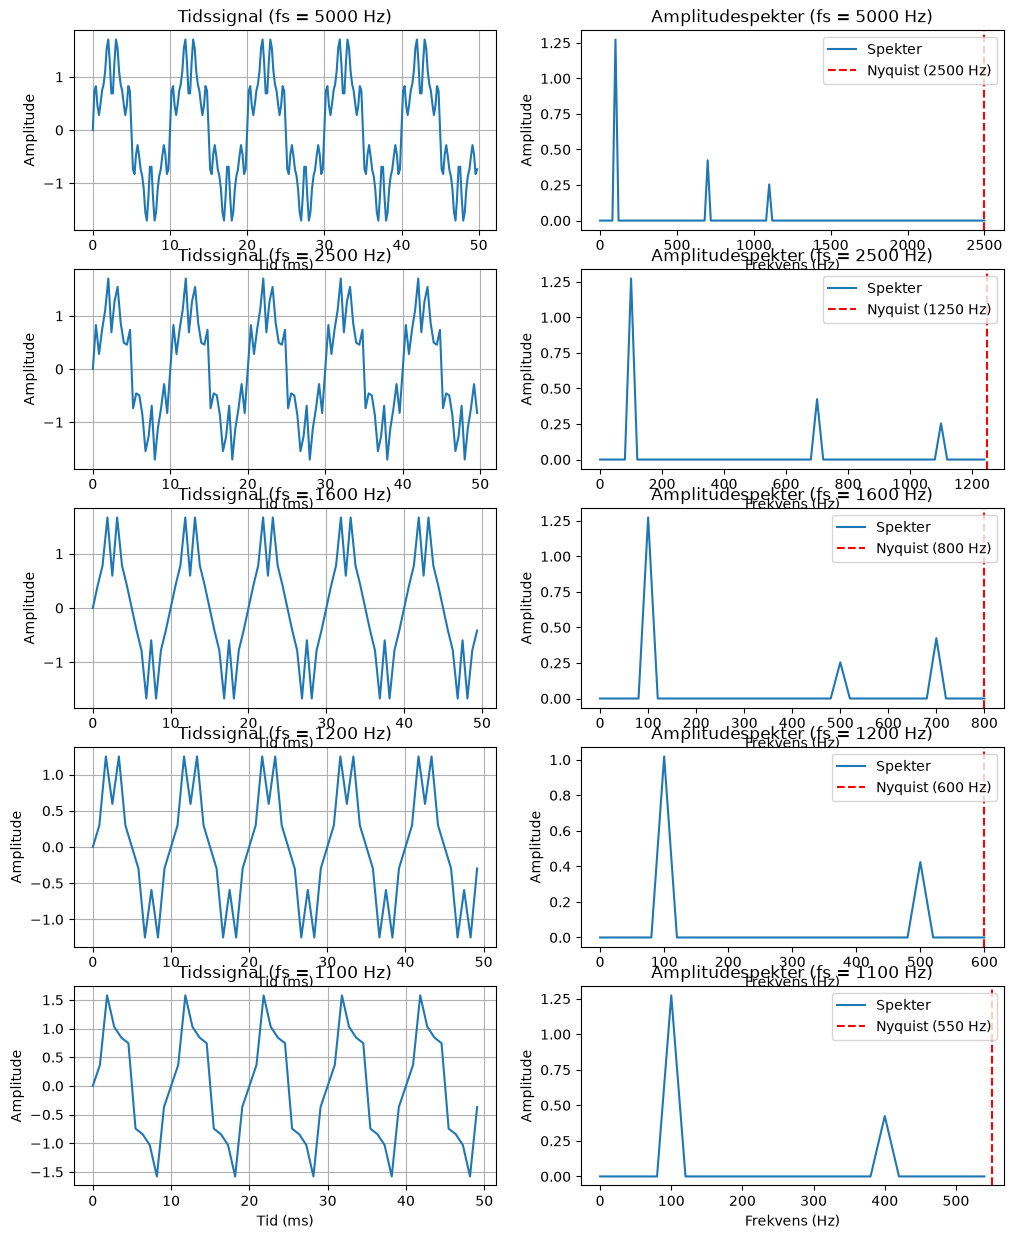

In [78]:
fig, axes = plt.subplots(len(f_s), 2, figsize=(12, 3 * len(f_s)))

for i, fs in enumerate(f_s):
    xx, tt = syn_sin(fk, Xk, fs, dur)
    freq, amplitude = amplitude_spectrum(xx, fs)
    ax_time = axes[i, 0]
    ax_freq = axes[i, 1]
    
    # Tidsplott
    ax_time.plot(tt * 1000, xx)
    ax_time.set_title(f"Tidssignal (fs = {fs} Hz)")
    ax_time.set_xlabel("Tid (ms)")
    ax_time.set_ylabel("Amplitude")
    ax_time.grid(True)
    
    # Frekvensplott
    ax_freq.plot(freq, amplitude, label="Spekter")
    
    #nyquistplott
    f_nyq = fs / 2
    ax_freq.axvline(f_nyq, color='r', linestyle='--', label=f'Nyquist ({f_nyq:.0f} Hz)')
    
    ax_freq.set_title(f"Amplitudespekter (fs = {fs} Hz)")
    ax_freq.set_xlabel("Frekvens (Hz)")
    ax_freq.set_ylabel("Amplitude")
    ax_freq.legend(loc='upper right')


5 ulike samplingfrekvenser f_s: 5000, 2500, 1600, 1200, 1100 Hz på det samme signalet med frekvensene 100, 700, 1100 Hz. Når frekvensen er større enn nyquistfrekvensen får vi aliasering hvor frekvensen representeres lavere enn den egentlig er fordi datamaskinen ikke klarer å skille den fra lavere frekvenser. Dette skjer gjennom folding rundt Nyquist-frekvensen. Frekvenskomponentene som ikke aliaseres kan observeres direkte i plottet.

F_s = 5000: Her får vi nyquistfrekvensen 5000/2 = 2500 Hz. 100, 700, 1100 er alle mindre enn F_N = 2500 Hz, og dermed blir det ingen aliasering, og alle komponentene kan observeres direkte.

F_s = 2500: F_N = 2500/2 = 1250 Hz. 100, 700, 1100 er fortsatt under F_N, så ingen aliasering her heller.

F_s = 1600: F_N = 1600/2 = 800 Hz. 1100 > F_N = 800 -> abs(1100 - 1600) = 500 Hz. 500 aliaseres fra 1100.

F_s = 1200: F_N = 1200/2 = 600 Hz. 700 & 1100 > 600 -> abs(700 - 1200) = 500 Hz, abs(1100 - 1200) = 100 Hz. Her får vi frekvensene 100, 500, 100 i plottet. Den opprinnelige komponenten på 100 Hz og den aliaserte komponenten fra 1100 Hz havner på samme frekvens. Bidragene fra komponentene kombineres, og vi får derfor én topp ved 100 Hz med amplitude på omtrent 1.2.

F_s = 1100: F_N = 1100/2 = 550 Hz. 700 & 1100 > 550 -> abs(700 - 1100) = 400 Hz, abs(1100 - 1100) = 0 Hz. 1100 Hz foldes til 0 Hz. Med fasen -pi/2 som brukes for denne komponenten, blir den ikke synlig som en egen topp i amplitudespekteret. Vi ser derfor bare toppene ved 100 Hz og 400 Hz.

Hva som skjer når to komponenter havner på samme frekvens i FFT-spekteret: 
Når to komponenter havner på samme frekvens i FFT-spekteret, kan de ikke lenger skilles fra hverandre og vises som én topp. Bidragene fra komponentene kombineres.

Hvordan tidsplottet endrer seg når samplingsfrekvensen reduseres:
Når samplingsfrekvensen reduseres får vi færre målepunkter, og tidsplottet blir derfor mindre detaljert. 

### 2.3 Firkantsignal

Presenter tidsplott og amplitudespekter for firkantsignalet og diskuter
de observerte harmoniske komponentene.


For hver figur:
- gi en kort figurtekst,
- oppgi hvilke parametere som ble brukt,
- pek ut relevante observasjoner (for eksempel FFT-topper eller
  foldede frekvenser).

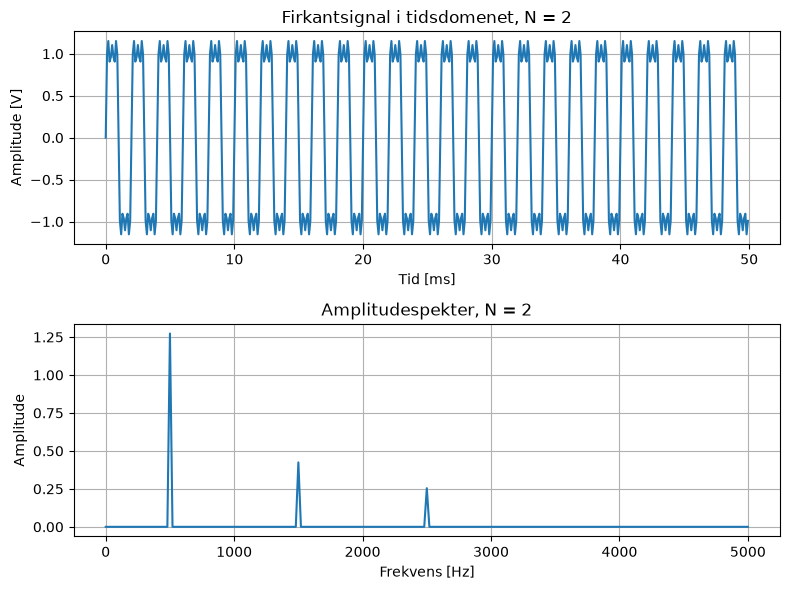

In [79]:
# Figur 1

fs = 4 * (2*N - 1) * F0
# Lager signalet med tildligere gitt funksjon
signal, t = syn_sin(
    fk=harmonics,
    Xk=Xk,
    fs=fs,
    dur=dur,
)

# Lager amplitude sprektrum med tidligere gitt funksjon
freq, amplitude = amplitude_spectrum(signal, fs)

# Initialiserer plottene som skal brukes
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6))

# Tidsplott
ax1.plot(t * 1000, signal)
ax1.set_title("Firkantsignal i tidsdomenet, N = 2")
ax1.set_xlabel("Tid [ms]")
ax1.set_ylabel("Amplitude [V]")
ax1.grid(True)

# Frekvensplott
ax2.plot(freq, amplitude)
ax2.set_title("Amplitudespekter, N = 2")
ax2.set_xlabel("Frekvens [Hz]")
ax2.set_ylabel("Amplitude")
ax2.grid(True)

plt.tight_layout()
plt.show()

**Figur 1**: Tidsplott og amplitudespekter for firkantsignal med F_0 = 500 Hz, A = 1.0 V og N = 2. Samplingsfrekvensen er f_s = 6000 Hz.

Når N = 2 har firkantsignalet kun de to første odde harmoniske komponentene. F_0 = 500 Hz, så grunnfrekvensen er 500 Hz, og den neste odde harmoniske komponenten er 3F_0 = 1500 Hz. Derfor viser amplitudespekteret topper ved 500 Hz og 1500 Hz.

To harmoniske komponenter er lite for et firkantsignal og gir kun en grov tilnærming. Vi kan se i tidsplottet at kantene er avrundet, så flere harmoniske komponenter trengs for å få et mer nøyaktig firkantsignal.

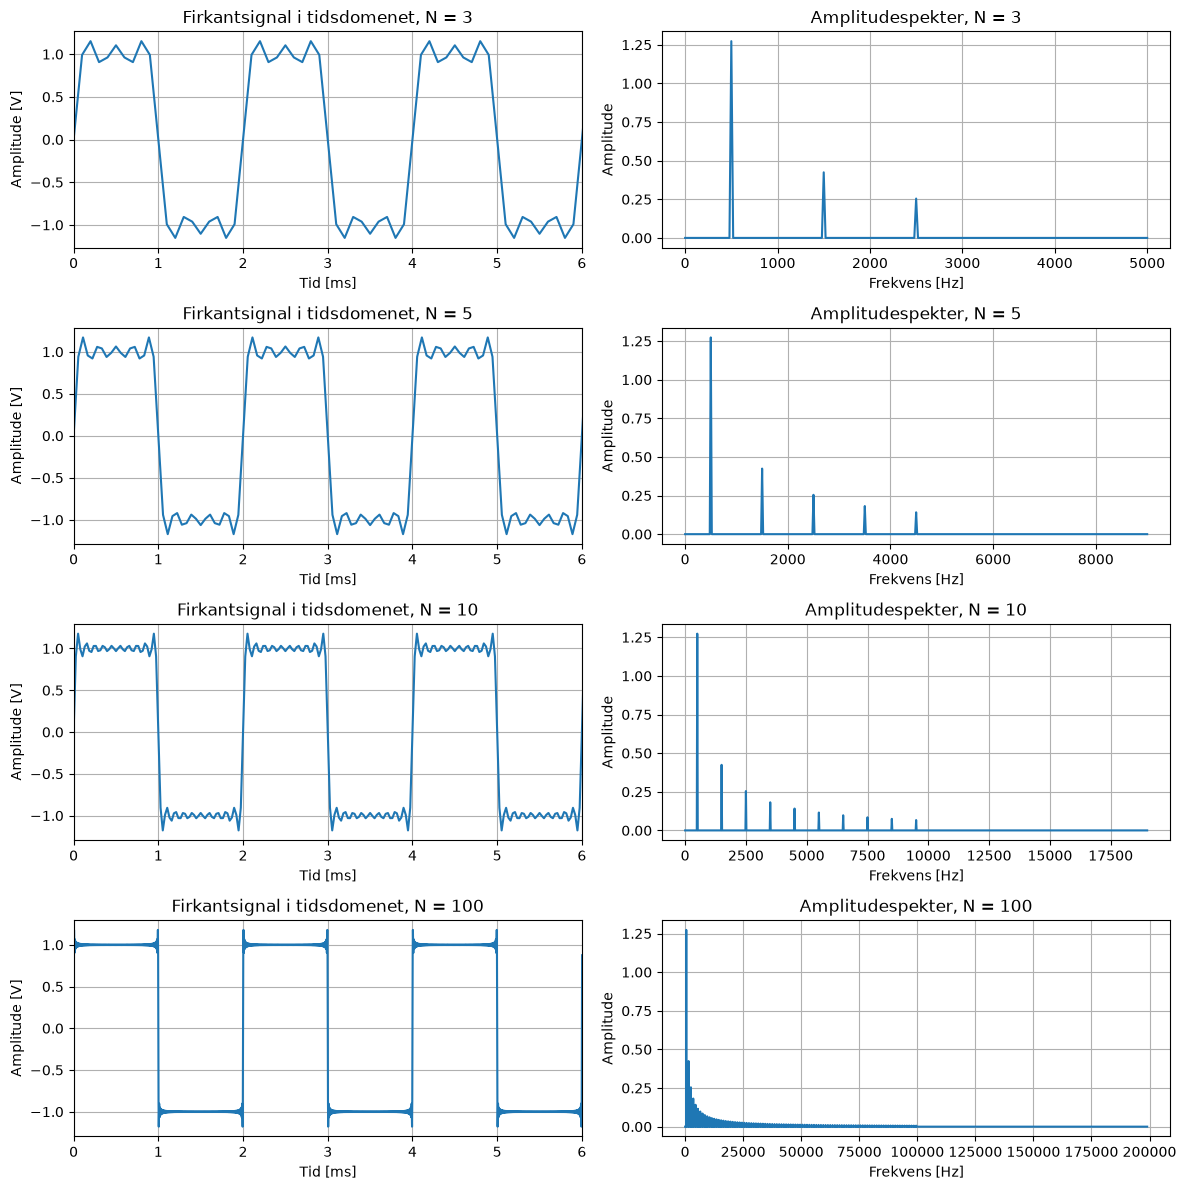

In [80]:
# Figur 2
N_values = [3, 5, 10, 100] # Verdier for antall harmoniske komponenter

# Initialiserer plottene som skal brukes
fig, axes = plt.subplots(len(N_values), 2, figsize=(12, 12))

# Går gjennom hver N-verdi og lager nytt signal og spekter
for i, N in enumerate(N_values):
    n = np.arange(1, 2*N, 2) # Oddetallene
    harmonics = n * F0 # oddeharmoniske av F0
    Ak = 4 * A / (np.pi * n) # Amplituden til hver harmoniske
    phik = -np.pi/2 * np.ones(N) # Fase til alle komponentene
    Xk = Ak * np.exp(1j * phik) # kombinerer amplitude og fase

    fs = 4 * (2*N - 1) * F0

    # Lager signalet med tidligere gitt funksjon
    signal, t = syn_sin(
        fk=harmonics,
        Xk=Xk,
        fs=fs,
        dur=dur,
    )

    # Lager amplitude sprektrum med tidligere gitt funksjon
    freq, amplitude = amplitude_spectrum(signal, fs)

    # Tidsplott
    axes[i, 0].plot(t * 1000, signal)
    axes[i, 0].set_xlim(0, 6)
    axes[i, 0].set_title(f"Firkantsignal i tidsdomenet, N = {N}")
    axes[i, 0].set_xlabel("Tid [ms]")
    axes[i, 0].set_ylabel("Amplitude [V]")
    axes[i, 0].grid(True)

    # Frekvensplott
    axes[i, 1].plot(freq, amplitude)
    axes[i, 1].set_title(f"Amplitudespekter, N = {N}")
    axes[i, 1].set_xlabel("Frekvens [Hz]")
    axes[i, 1].set_ylabel("Amplitude")
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

**Figur 2**: Tidsplott og amplitudespekter for firkantsignal med F_0 = 500 Hz, A = 1.0 V og N = 3, 5, 10 og 100. Samplingsfrekvensen tilpasses antallet harmoniske komponenter etter f_s = 4(2N-1)F_0.

N verdien forteller hvor mange odde harmoniske komponenter som er i firkantsignalet. Når for eksempel N = 3 inneholder firkantsignalet 500hz, 1500hz og 2500hz. Dette ser vi som topper i amplitudespekteret ved de nevnte frekvensene. Jo større N er, desto flere harmoniske komponenter med høyere frekvenser får vi.

I tidsplottene ser vi at når N øker, blir firkantsignalet mer firkantet og presist. Høyere og flere harmoniske komponenter bidrar til at signalet får raske overganger, som gir signalet bratte kanter, og flate topper og bunner.

Samtidig ser vi små svingninger og litt overshoot nær de bratte overgangene i 
signalet. Dette skjer fordi vi prøver å lage et signal med skarpe kanter ved å 
summere flere sinuskomponenter. Sinuskomponentene er glatte kurver, så de klarer 
ikke å lage en helt pergekt vinkel. Når N øker, blir signalet mer nøyaktig, men 
det er fortsatt litt overshoot nær kantene.

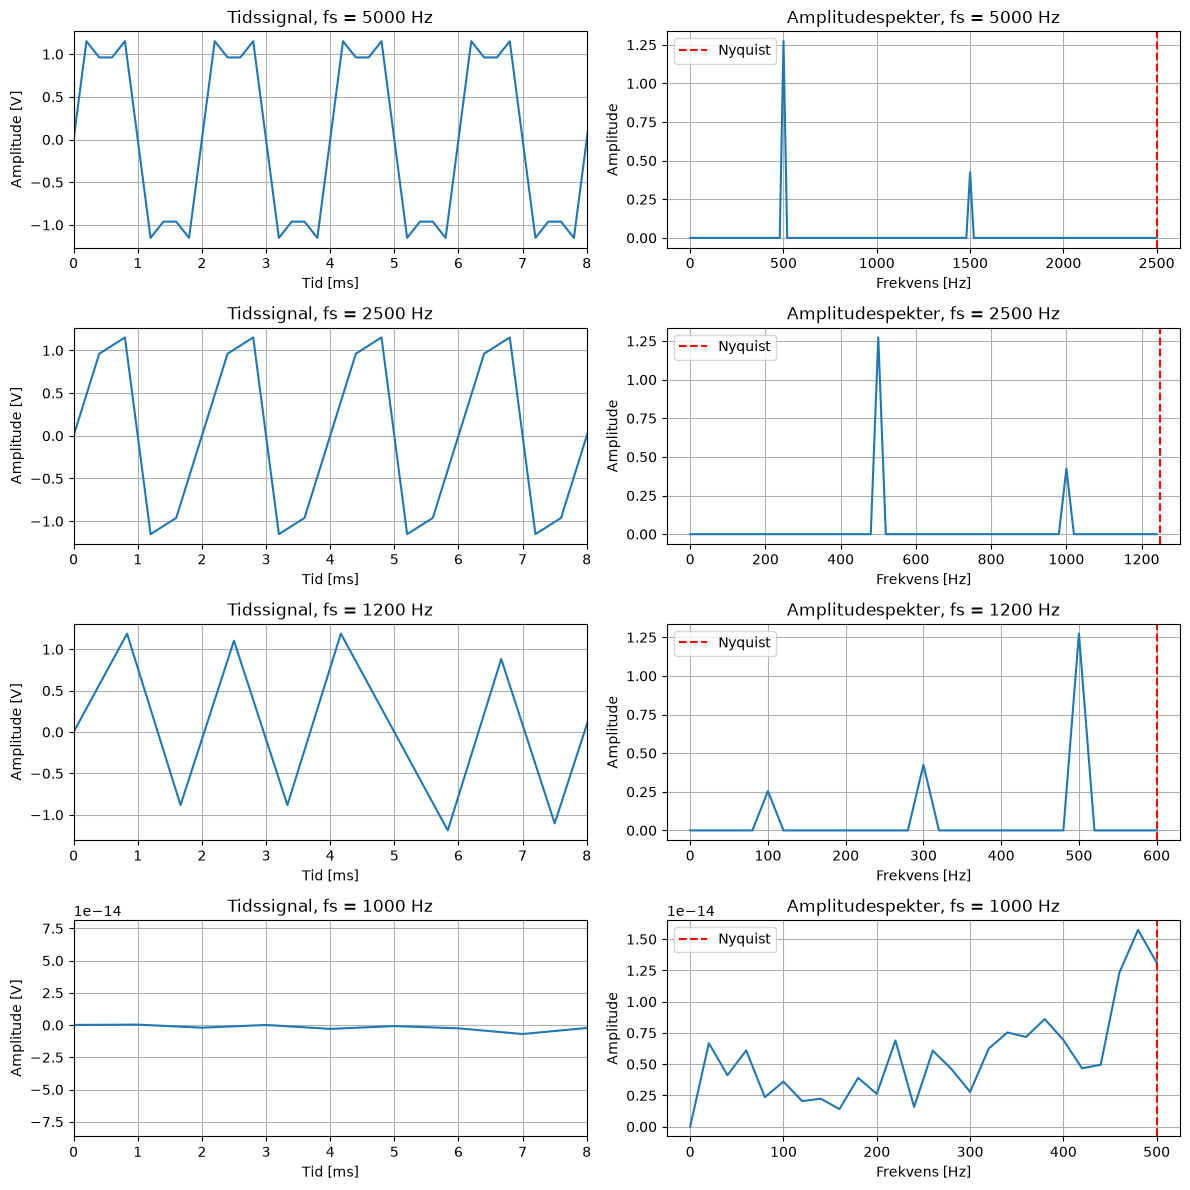

In [81]:
# Figur 3
N = 3  # antall harmoniske

n = np.arange(1, 2*N, 2)  # oddetallene
harmonics = n * F0  # odde harmoniske av F0
Ak = 4 * A / (np.pi * n)  # amplituden til hver harmoniske
phik = -np.pi/2 * np.ones(N)  # fase til alle komponentene
Xk = Ak * np.exp(1j * phik)  # kombinerer amplitude og fase

sampling_rates = [5000, 2500, 1200, 1000]  # samplingsfrekvensene

# Initialiserer plottene som skal brukes
fig, axes = plt.subplots(len(sampling_rates), 2, figsize=(12, 12))

# Itererer over sampling_rates for å lage ett plot for hver samplingsfrekvens
for i, fs in enumerate(sampling_rates):
    # Lager signalet med tidligere gitt funksjon
    signal, t = syn_sin(
        fk=harmonics,
        Xk=Xk,
        fs=fs,
        dur=dur,
    )

    # Lager amplitudespekteret med tidligere gitt funksjon
    freq, amplitude = amplitude_spectrum(signal, fs)

    # Regner ut Nyquist-frekvensen
    f_nyq = fs / 2

    # Tidsplott
    axes[i, 0].plot(t * 1000, signal)
    axes[i, 0].set_xlim(0, 8)
    axes[i, 0].set_title(f"Tidssignal, fs = {fs} Hz")
    axes[i, 0].set_xlabel("Tid [ms]")
    axes[i, 0].set_ylabel("Amplitude [V]")
    axes[i, 0].grid(True)

    # Frekvensplott
    axes[i, 1].plot(freq, amplitude)
    axes[i, 1].axvline(f_nyq, color="r", linestyle="--", label="Nyquist")
    axes[i, 1].set_title(f"Amplitudespekter, fs = {fs} Hz")
    axes[i, 1].set_xlabel("Frekvens [Hz]")
    axes[i, 1].set_ylabel("Amplitude")
    axes[i, 1].legend()
    axes[i, 1].grid(True)

plt.tight_layout()
plt.show()

**Figur 3**: Tidsplott og amplitudespekter for firkantsignal med F_0 = 500 Hz, A = 1.0 V og N = 3, ved samplingsfrekvensene f_s = 5000, 2500, 1200 og 1000 Hz. De tre harmoniske komponentene er 500 Hz, 1500 Hz og 2500 Hz. Den røde stiplede linjen markerer Nyquist-frekvensen for hver samplingsfrekvens.

Når N = 3 består firkantsignalet av frekvensene 500 Hz, 1500 Hz og 2500 Hz. 
For hver samplingsfrekvens sammenligner vi disse frekvensene med 
Nyquist-frekvensen, som er fs/2. Frekvenser over Nyquist-frekvensen 
aliaseres og vises som lavere frekvenser i amplitudespekteret.

Ved fs = 5000 Hz er Nyquist-frekvensen 2500 Hz. Frekvensene 500 og 1500 hertz ligger under Nyquist-frekvensen, mens 2500 ligger akkurat på grensen. Når fs er lik 2500 Hz, 1200 Hz og 1000 Hz, ligger 
flere av de harmoniske komponentene over Nyquist-frekvensen. Da blir de foldet 
til lavere frekvenser, og amplitudespekteret viser ikke lenger de opprinnelige 
harmoniske komponentene riktig.

Ved f_s=1000 Hz er Nyquist-frekvensen 500 Hz. Alle de opprinnelige harmoniske komponentene ligger da på eller over Nyquist-grensen. Dette gir en svært dårlig representasjon av det opprinnelige firkantsignalet. Aliasing påvirker derfor både amplitudespekteret og tidsplottet, siden de høyere harmoniske komponentene er viktige for å danne de bratte kantene i firkantsignalet.

## 3. Diskusjon

Tolk resultatene og sammenlign med forventningene fra teorien.

Diskuter:
- om FFT-spekteret stemmer med de forventede frekvenskomponentene,
- når og hvorfor aliasing oppstår,
- hvordan harmoniske komponenter påvirkes av sampling,
- eventuelle avvik eller overraskende resultater.

## 4. Konklusjon

Oppsummer de viktigste resultatene fra laboppgaven.

Kommenter kort:
- hva du har lært om sampling og frekvensanalyse?
Vi har lært at sampling bestemmer hvor godt et signal kan representeres digitalt. FFT kan brukes til å vise hvilke frekvenser et signal består av, og gjør det lettere å sammenligne tidsdomenet og frekvensdomenet. Laben viste også at frekvensoppløsning og samplingsfrekvens har betydning for hvor tydelig og riktig spekteret blir.

- hvilke fenomener som ble observert?
Vi observerte først at de forventede frekvenskomponentene kunne finnes igjen i amplitudespekteret. Videre så vi at aliasing oppstår når samplingsfrekvensen er for lav i forhold til frekvensene i signalet. I tillegg observerte vi at firkantsignalet blir mer nøyaktig når flere harmoniske komponenter tas med, men også at det oppstår små spikes eller overshoot nær de bratte overgangene i signalet.

- hva som var mest utfordrende eller interessant?
Det mest utfordrende var å forstå aliasing og hvordan Nyquist-frekvensen henger sammen med dette. Det var også interessant å se hvor stor forskjell samplingsfrekvensen kan ha for hvordan et signal ser ut i frekvensdomenet. Firkantsignalet var spesielt nyttig fordi det viste ganske tydelig hvordan flere sinuskomponenter sammen kan lage en annen signalform.